In [1]:
## Example 1: Analyzing Tesla (TSLA) Return Distribution

### Dataset Description
Tesla Inc. (TSLA) is a high-profile electric vehicle company known for 
extreme price volatility. We analyze 10 years of daily returns to test 
whether they follow a normal distribution.

**Source:** Yahoo Finance  
**Period:** 2014-2024  
**Relevance:** Individual stocks often show more extreme behavior than indices

### Problem Setup
We will test if Tesla's daily returns are normally distributed by:
1. Calculating descriptive statistics
2. Visualizing the distribution
3. Running normality tests
4. Comparing tail behavior to normal expectations

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [8]:
# Step 1: Download Tesla Data

tesla = yf.download("TSLA", start="2014-01-01", end="2024-01-01", progress=False)
tesla_prices = tesla['Close']
print(f"Tesla: {len(tesla_prices)} trading days downloaded")

Tesla: 2516 trading days downloaded


In [14]:
# Step 2: Calculate Log Returns
tesla_returns = np.log(tesla_prices / tesla_prices.shift(1)).dropna()
tesla_ret = tesla_returns.values.flatten()  # Flatten to 1D array
print(f"Tesla: {len(tesla_ret)} daily returns calculated")

Tesla: 2515 daily returns calculated


In [16]:
# calculating Statistics
print("\n=== Tesla Statistics ===")
print(f"Mean (%):          {np.mean(tesla_ret) * 100:.4f}")
print(f"Std Dev (%):       {np.std(tesla_ret) * 100:.4f}")
print(f"Skewness:          {stats.skew(tesla_ret):.4f}")
print(f"Excess Kurtosis:   {stats.kurtosis(tesla_ret):.4f}")
print(f"Min (%):           {np.min(tesla_ret) * 100:.4f}")
print(f"Max (%):           {np.max(tesla_ret) * 100:.4f}")


=== Tesla Statistics ===
Mean (%):          0.1277
Std Dev (%):       3.4999
Skewness:          -0.1228
Excess Kurtosis:   4.5397
Min (%):           -23.6518
Max (%):           18.1445


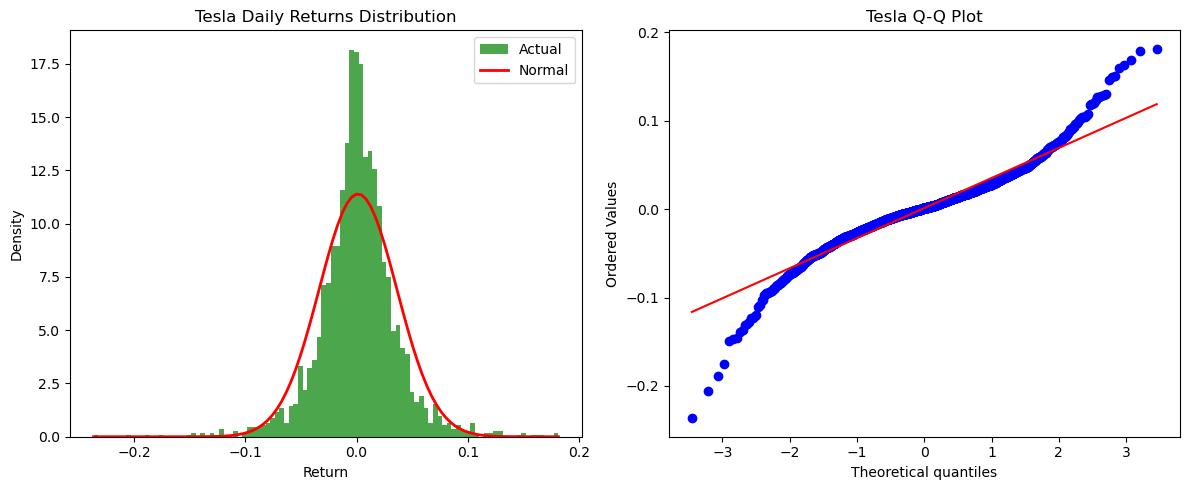

In [20]:
# Step 4: Visualize Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(tesla_ret, bins=100, density=True, alpha=0.7, color='green', label='Actual')
x = np.linspace(tesla_ret.min(), tesla_ret.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, tesla_ret.mean(), tesla_ret.std()), 'r-', lw=2, label='Normal')
axes[0].set_title('Tesla Daily Returns Distribution')
axes[0].set_xlabel('Return')
axes[0].set_ylabel('Density')
axes[0].legend()

# Q-Q Plot
stats.probplot(tesla_ret, dist="norm", plot=axes[1])
axes[1].set_title('Tesla Q-Q Plot')

plt.tight_layout()
plt.savefig('tesla_distribution.png', dpi=150)
plt.show()

In [22]:
# Step 5: Normality Tests

print("\n=== Normality Tests ===")

# Jarque-Bera Test
jb_stat, jb_pvalue = stats.jarque_bera(tesla_ret)
print(f"Jarque-Bera: statistic={jb_stat:.2f}, p-value={jb_pvalue:.2e}")

# Shapiro-Wilk Test
sw_stat, sw_pvalue = stats.shapiro(tesla_ret[:5000])
print(f"Shapiro-Wilk: statistic={sw_stat:.4f}, p-value={sw_pvalue:.2e}")

if jb_pvalue < 0.05:
    print("Result: REJECT normality (p < 0.05)")
else:
    print("Result: Cannot reject normality")


=== Normality Tests ===
Jarque-Bera: statistic=2165.93, p-value=0.00e+00
Shapiro-Wilk: statistic=0.9440, p-value=6.81e-30
Result: REJECT normality (p < 0.05)


In [26]:
# Step 6: Tail Analysis

std = tesla_ret.std()

print("\n=== Tail Analysis ===")
print(f"{'Event':<20} {'Actual':<10} {'Normal Expects':<15} {'Ratio':<10}")
print("-" * 55)

for n_std in [2, 3, 4]:
    actual = (np.abs(tesla_ret) > n_std * std).sum()
    expected = len(tesla_ret) * 2 * (1 - stats.norm.cdf(n_std))
    ratio = actual / expected if expected > 0 else np.inf
    print(f"Beyond {n_std} std dev     {actual:<10} {expected:<15.1f} {ratio:<10.1f}x")



=== Tail Analysis ===
Event                Actual     Normal Expects  Ratio     
-------------------------------------------------------
Beyond 2 std dev     147        114.4           1.3       x
Beyond 3 std dev     40         6.8             5.9       x
Beyond 4 std dev     15         0.2             94.2      x


In [28]:
# Interpretation

print("\n=== Interpretation ===")
print("""
Tesla shows even more extreme behavior than market indices:
- High excess kurtosis indicates very fat tails
- Negative skewness shows more extreme drops than gains
- Extreme events happen much more often than normal predicts
- Individual stocks are riskier than diversified indices
""")


=== Interpretation ===

Tesla shows even more extreme behavior than market indices:
- High excess kurtosis indicates very fat tails
- Negative skewness shows more extreme drops than gains
- Extreme events happen much more often than normal predicts
- Individual stocks are riskier than diversified indices

